In [3]:
!pip install scikit-learn pandas matplotlib seaborn

     |████████████████████████████████| 294 kB 40 kB/s eta 0:00:01


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [5]:
# Load training data
newsgroups_train = fetch_20newsgroups(
    subset='train',
    remove=('headers', 'footers', 'quotes')
)

# Load testing data
newsgroups_test = fetch_20newsgroups(
    subset='test',
    remove=('headers', 'footers', 'quotes')
)

print("Number of training documents:", len(newsgroups_train.data))
print("Number of testing documents:", len(newsgroups_test.data))
print("Number of categories:", len(newsgroups_train.target_names))

print("\nCategories:")
for i, category in enumerate(newsgroups_train.target_names):
    print(i, "-", category)


Number of training documents: 11314
Number of testing documents: 7532
Number of categories: 20

Categories:
0 - alt.atheism
1 - comp.graphics
2 - comp.os.ms-windows.misc
3 - comp.sys.ibm.pc.hardware
4 - comp.sys.mac.hardware
5 - comp.windows.x
6 - misc.forsale
7 - rec.autos
8 - rec.motorcycles
9 - rec.sport.baseball
10 - rec.sport.hockey
11 - sci.crypt
12 - sci.electronics
13 - sci.med
14 - sci.space
15 - soc.religion.christian
16 - talk.politics.guns
17 - talk.politics.mideast
18 - talk.politics.misc
19 - talk.religion.misc


In [6]:
# Display one example document
print("Category:", newsgroups_train.target_names[newsgroups_train.target[0]])
print("\nDocument:\n")
print(newsgroups_train.data[0][:2000])


Category: rec.autos

Document:

I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.


In [7]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=50000,
    min_df=2
)

X_train = vectorizer.fit_transform(newsgroups_train.data)
X_test = vectorizer.transform(newsgroups_test.data)

y_train = newsgroups_train.target
y_test = newsgroups_test.target

print("Training feature matrix shape:", X_train.shape)
print("Testing feature matrix shape:", X_test.shape)


Training feature matrix shape: (11314, 39115)
Testing feature matrix shape: (7532, 39115)


In [8]:
# Create Multinomial Naive Bayes model
mnb = MultinomialNB()

# Train the model
mnb.fit(X_train, y_train)

# Make predictions
y_pred_mnb = mnb.predict(X_test)

print("Multinomial Naive Bayes training completed.")


Multinomial Naive Bayes training completed.


In [9]:
accuracy_mnb = accuracy_score(y_test, y_pred_mnb)

precision_mnb = precision_score(
    y_test,
    y_pred_mnb,
    average='weighted'
)

recall_mnb = recall_score(
    y_test,
    y_pred_mnb,
    average='weighted'
)

f1_mnb = f1_score(
    y_test,
    y_pred_mnb,
    average='weighted'
)

print("Multinomial Naive Bayes Results")
print("--------------------------------")
print("Accuracy :", round(accuracy_mnb, 4))
print("Precision:", round(precision_mnb, 4))
print("Recall   :", round(recall_mnb, 4))
print("F1-score :", round(f1_mnb, 4))


Multinomial Naive Bayes Results
--------------------------------
Accuracy : 0.6816
Precision: 0.7335
Recall   : 0.6816
F1-score : 0.6684


In [10]:
print(classification_report(
    y_test,
    y_pred_mnb,
    target_names=newsgroups_test.target_names
))


                          precision    recall  f1-score   support

             alt.atheism       0.74      0.20      0.32       319
           comp.graphics       0.65      0.69      0.67       389
 comp.os.ms-windows.misc       0.66      0.60      0.63       394
comp.sys.ibm.pc.hardware       0.61      0.74      0.67       392
   comp.sys.mac.hardware       0.78      0.68      0.73       385
          comp.windows.x       0.81      0.76      0.79       395
            misc.forsale       0.78      0.78      0.78       390
               rec.autos       0.81      0.73      0.77       396
         rec.motorcycles       0.85      0.75      0.80       398
      rec.sport.baseball       0.91      0.80      0.85       397
        rec.sport.hockey       0.57      0.93      0.71       399
               sci.crypt       0.64      0.79      0.70       396
         sci.electronics       0.71      0.53      0.61       393
                 sci.med       0.88      0.76      0.81       396
         

In [11]:
# Convert documents into binary word-presence features
binary_vectorizer = CountVectorizer(
    stop_words='english',
    binary=True,
    max_features=50000,
    min_df=2
)

X_train_binary = binary_vectorizer.fit_transform(newsgroups_train.data)
X_test_binary = binary_vectorizer.transform(newsgroups_test.data)

print("Binary training matrix shape:", X_train_binary.shape)
print("Binary testing matrix shape:", X_test_binary.shape)


Binary training matrix shape: (11314, 39115)
Binary testing matrix shape: (7532, 39115)


In [12]:
# Create Bernoulli Naive Bayes model
bnb = BernoulliNB()

# Train the model
bnb.fit(X_train_binary, y_train)

# Make predictions
y_pred_bnb = bnb.predict(X_test_binary)

print("Bernoulli Naive Bayes training completed.")


Bernoulli Naive Bayes training completed.


In [13]:
accuracy_bnb = accuracy_score(y_test, y_pred_bnb)

precision_bnb = precision_score(
    y_test,
    y_pred_bnb,
    average='weighted'
)

recall_bnb = recall_score(
    y_test,
    y_pred_bnb,
    average='weighted'
)

f1_bnb = f1_score(
    y_test,
    y_pred_bnb,
    average='weighted'
)

print("Bernoulli Naive Bayes Results")
print("-----------------------------")
print("Accuracy :", round(accuracy_bnb, 4))
print("Precision:", round(precision_bnb, 4))
print("Recall   :", round(recall_bnb, 4))
print("F1-score :", round(f1_bnb, 4))


Bernoulli Naive Bayes Results
-----------------------------
Accuracy : 0.4851
Precision: 0.627
Recall   : 0.4851
F1-score : 0.4808


In [14]:
print(classification_report(
    y_test,
    y_pred_bnb,
    target_names=newsgroups_test.target_names
))


                          precision    recall  f1-score   support

             alt.atheism       0.64      0.20      0.31       319
           comp.graphics       0.55      0.52      0.54       389
 comp.os.ms-windows.misc       0.50      0.01      0.02       394
comp.sys.ibm.pc.hardware       0.46      0.69      0.55       392
   comp.sys.mac.hardware       0.32      0.81      0.46       385
          comp.windows.x       0.83      0.41      0.55       395
            misc.forsale       0.87      0.66      0.75       390
               rec.autos       0.41      0.70      0.52       396
         rec.motorcycles       0.19      0.93      0.32       398
      rec.sport.baseball       0.71      0.78      0.74       397
        rec.sport.hockey       0.99      0.52      0.69       399
               sci.crypt       0.78      0.38      0.51       396
         sci.electronics       0.57      0.51      0.54       393
                 sci.med       0.89      0.36      0.51       396
         

In [15]:
results = pd.DataFrame({
    'Model': [
        'Multinomial Naive Bayes',
        'Bernoulli Naive Bayes'
    ],
    'Accuracy': [
        accuracy_mnb,
        accuracy_bnb
    ],
    'Precision': [
        precision_mnb,
        precision_bnb
    ],
    'Recall': [
        recall_mnb,
        recall_bnb
    ],
    'F1-Score': [
        f1_mnb,
        f1_bnb
    ]
})

results


,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.681625,0.733481,0.681625,0.668428
1,Bernoulli Naive Bayes,0.485130,0.627034,0.485130,0.480839


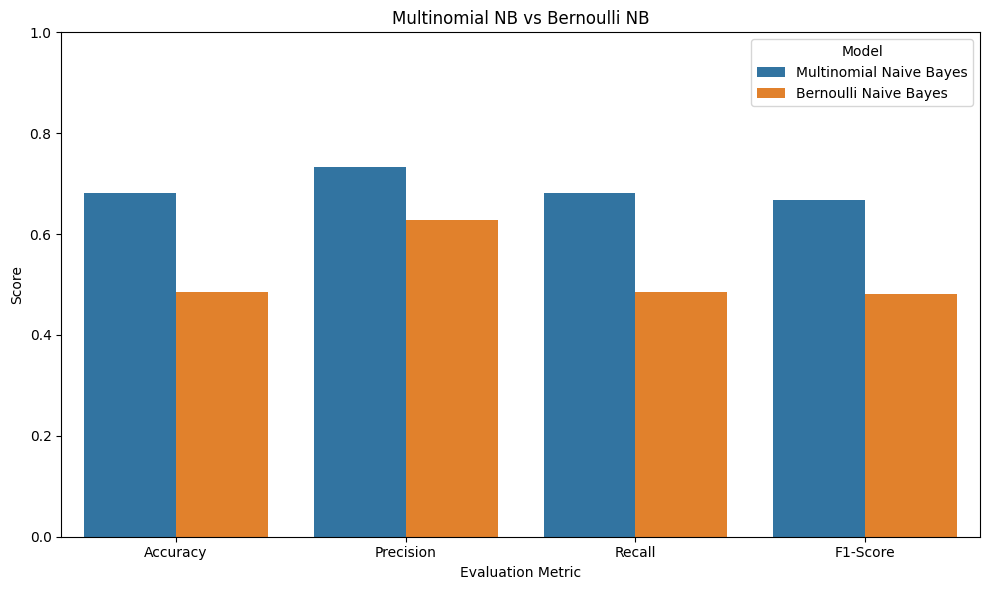

In [16]:
# Convert results to a format suitable for plotting
plot_data = results.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x='Metric',
    y='Score',
    hue='Model'
)

plt.title('Multinomial NB vs Bernoulli NB')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.xlabel('Evaluation Metric')
plt.legend(title='Model')
plt.tight_layout()
plt.show()
